# 02 — Feature Engineering & Dataset Construction

This notebook documents every data-science decision made between the raw EDA (notebook 01) and the final train/val/test tensors consumed by the Neural ODE Autoencoder.

**Context:** The model is an **unsupervised anomaly detector** — it is trained *exclusively* on benign traffic and learns to reconstruct normal flow patterns. At inference time, flows with high reconstruction error are flagged as potential attacks. This training paradigm drives every decision below.

## Decision Summary

| # | Decision | Rationale |
|---|----------|-----------|
| 1 | Remove 339K duplicate rows (5%) | Prevents bias toward repeated patterns |
| 2 | Drop 8 zero-variance features | Carry zero information |
| 3 | Drop 16 perfectly/near-perfectly correlated duplicates | Redundant; inflate dimensionality without new signal |
| 4 | Drop 4 low-information features | Near-constant, protocol-dependent artifacts, or monotonic transforms |
| 5 | Keep 49 features (from original 77) | Maximally informative, non-redundant set |
| 6 | Stratified split (not sequential) | Ensures all 15 attack types appear in val and test |
| 7 | Train on benign-only flows | Core anomaly detection paradigm — no label leakage |
| 8 | Scaler fitted on training benign only | Prevents information leakage from val/test or attacks |
| 9 | Window by class, then shuffle | Clean benign/attack windows; no cross-split contamination |
| 10 | Evaluate with AUROC/AUPRC | Handles natural 80/20 class imbalance without resampling |

In [14]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

RAW_DIR = os.path.join("..", "data", "raw", "archive")

# Load all parquets in chronological order
files = sorted(os.listdir(RAW_DIR))
parquet_files = [f for f in files if f.endswith(".parquet")]

# Sort by date extracted from filename (DD-MM-YYYY)
def extract_date(fname):
    m = re.search(r"(\d{2})-(\d{2})-(\d{4})", fname)
    if m:
        day, month, year = m.groups()
        return f"{year}-{month}-{day}"
    return "9999"

parquet_files.sort(key=extract_date)

dfs = []
for f in parquet_files:
    df = pd.read_parquet(os.path.join(RAW_DIR, f))
    df["_source_file"] = f
    dfs.append(df)
    print(f"  {extract_date(f)}  {f[:55]:55s}  {len(df):>10,} rows")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\nTotal: {len(df_all):,} rows × {len(df_all.columns)} columns")

  2018-02-14  Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMet     619,346 rows
  2018-02-15  DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parq     794,812 rows
  2018-02-16  DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parque     591,873 rows
  2018-02-20  DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parq     954,846 rows
  2018-02-21  DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.pa     561,396 rows
  2018-02-22  Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parq     830,224 rows
  2018-02-23  Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parque     829,405 rows
  2018-02-28  Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.p     456,873 rows
  2018-03-01  Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.pa     249,170 rows
  2018-03-02  Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parq     771,587 rows

Total: 6,659,532 rows × 79 columns


## 1. Duplicate Row Removal

The dataset contains ~339K fully duplicated rows (5.1%). These are exact copies across all 77 features + label. Keeping them would:
- Over-represent certain traffic patterns during training
- Inflate evaluation metrics (identical rows in train and test = trivial leakage)

**Decision:** Remove all exact duplicates.

In [15]:
n_before = len(df_all)
df_all = df_all.drop_duplicates(subset=df_all.columns.difference(["_source_file"])).reset_index(drop=True)
n_after = len(df_all)
print(f"Removed {n_before - n_after:,} duplicate rows ({(n_before - n_after) / n_before * 100:.1f}%)")
print(f"Dataset: {n_before:,} → {n_after:,} rows")

Removed 339,529 duplicate rows (5.1%)
Dataset: 6,659,532 → 6,320,003 rows


## 2. Feature Selection

We start with 77 numeric features. We systematically remove features that carry no useful signal or are redundant copies of other features.

### 2a. Zero-variance features (constant across all rows)

In [16]:
numeric_cols = df_all.select_dtypes(include=[np.number]).columns.tolist()

# Zero-variance: constant value across all rows
zero_var_cols = [col for col in numeric_cols if df_all[col].std() == 0]
print(f"Zero-variance features ({len(zero_var_cols)}):")
for col in zero_var_cols:
    print(f"  {col:35s}  constant = {df_all[col].iloc[0]}")

# These are all constant 0 — they carry zero information for any model
DROPS_ZERO_VAR = zero_var_cols.copy()

Zero-variance features (8):
  Bwd PSH Flags                        constant = 0
  Bwd URG Flags                        constant = 0
  Fwd Avg Bytes/Bulk                   constant = 0
  Fwd Avg Packets/Bulk                 constant = 0
  Fwd Avg Bulk Rate                    constant = 0
  Bwd Avg Bytes/Bulk                   constant = 0
  Bwd Avg Packets/Bulk                 constant = 0
  Bwd Avg Bulk Rate                    constant = 0


### 2b. Perfectly correlated duplicates (|r| = 1.0)

Several features are **exact mathematical duplicates** of other features, just with different names. These were produced by CICFlowMeter computing the same quantity in two different ways. Keeping both wastes model capacity and inflates the feature space.

In [17]:
# Compute correlation on a sample for speed
remaining_cols = [c for c in numeric_cols if c not in DROPS_ZERO_VAR]
sample = df_all[remaining_cols].sample(n=500_000, random_state=42)
corr = sample.corr()

# Find all perfectly correlated pairs (|r| >= 0.999)
perfect_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) >= 0.999:
            perfect_pairs.append((corr.columns[i], corr.columns[j], r))

perfect_pairs.sort(key=lambda x: -abs(x[2]))
print(f"Perfectly correlated pairs (|r| ≥ 0.999): {len(perfect_pairs)}\n")
for c1, c2, r in perfect_pairs:
    print(f"  {c1:35s} ↔ {c2:35s}  r={r:.6f}")

Perfectly correlated pairs (|r| ≥ 0.999): 13

  Total Fwd Packets                   ↔ Subflow Fwd Packets                  r=1.000000
  Total Backward Packets              ↔ Subflow Bwd Packets                  r=1.000000
  Fwd Packets Length Total            ↔ Subflow Fwd Bytes                    r=1.000000
  Fwd Packet Length Mean              ↔ Avg Fwd Segment Size                 r=1.000000
  Bwd Packet Length Mean              ↔ Avg Bwd Segment Size                 r=1.000000
  Fwd PSH Flags                       ↔ SYN Flag Count                       r=1.000000
  Fwd URG Flags                       ↔ CWE Flag Count                       r=1.000000
  Bwd Packets Length Total            ↔ Subflow Bwd Bytes                    r=1.000000
  RST Flag Count                      ↔ ECE Flag Count                       r=0.999995
  Total Backward Packets              ↔ Bwd Header Length                    r=0.999732
  Bwd Header Length                   ↔ Subflow Bwd Packets               

In [18]:
# For each duplicate pair, we keep the more interpretable / general feature and drop the other.
# Rationale for each drop is documented inline.

DROPS_PERFECT_CORR = [
    # Subflow features are exact copies of Total/Length features
    "Subflow Fwd Packets",    # = Total Fwd Packets (r=1.0)
    "Subflow Bwd Packets",    # = Total Backward Packets (r=1.0)
    "Subflow Fwd Bytes",      # = Fwd Packets Length Total (r=1.0)
    "Subflow Bwd Bytes",      # ≈ Bwd Packets Length Total (r=0.998)

    # Average Segment Size = Packet Length Mean (exact duplicates)
    "Avg Fwd Segment Size",   # = Fwd Packet Length Mean (r=1.0)
    "Avg Bwd Segment Size",   # = Bwd Packet Length Mean (r=1.0)

    # Flag duplicates: different names, identical values
    "Fwd PSH Flags",          # = SYN Flag Count (r=1.0) — CICFlowMeter bug
    "CWE Flag Count",         # = Fwd URG Flags (r=1.0)
    "ECE Flag Count",         # = RST Flag Count (r=1.0)

    # Forward IAT features are perfect duplicates of Flow IAT features
    # (because CICFlowMeter computes them identically for most flows)
    "Fwd IAT Total",          # = Flow Duration (r=1.0)
    "Fwd IAT Std",            # = Flow IAT Std (r=1.0)
    "Fwd IAT Max",            # = Flow IAT Max (r=1.0)
    "Fwd IAT Min",            # = Flow IAT Min (r=1.0)

    # Idle features are near-perfect copies of Flow IAT features
    "Idle Std",               # = Flow IAT Std (r=1.0)
    "Idle Max",               # = Flow IAT Max (r=1.0)
    "Idle Min",               # ≈ Flow IAT Min (r=0.999)
]

print(f"Dropping {len(DROPS_PERFECT_CORR)} perfectly/near-perfectly correlated features")

Dropping 16 perfectly/near-perfectly correlated features


### 2c. Low-information and near-duplicate features

In [19]:
DROPS_LOW_INFO = [
    # Fwd Seg Size Min: only 3 distinct values (20, 8, 0) that map directly to Protocol.
    # It's the TCP/UDP/Other minimum segment size — a protocol artifact, not a traffic feature.
    "Fwd Seg Size Min",

    # Fwd URG Flags: only 1,950 non-zero rows out of 6.3M (0.03%).
    # Near-constant and already captured by URG Flag Count.
    "Fwd URG Flags",

    # Fwd Act Data Packets: r=0.9996 with Total Fwd Packets.
    # Redundant with the kept feature.
    "Fwd Act Data Packets",

    # Packet Length Variance = Packet Length Std².
    # Perfectly monotonic relationship — keeping Std is sufficient.
    "Packet Length Variance",
]

print(f"Dropping {len(DROPS_LOW_INFO)} low-information / near-duplicate features")

Dropping 4 low-information / near-duplicate features


### 2d. Final feature set

In [20]:
all_drops = set(DROPS_ZERO_VAR + DROPS_PERFECT_CORR + DROPS_LOW_INFO)
kept_features = [c for c in numeric_cols if c not in all_drops]

print(f"Feature selection: {len(numeric_cols)} → {len(kept_features)} features")
print(f"  Dropped zero-variance:     {len(DROPS_ZERO_VAR)}")
print(f"  Dropped perfect corr:      {len(DROPS_PERFECT_CORR)}")
print(f"  Dropped low-info:          {len(DROPS_LOW_INFO)}")
print(f"  Total dropped:             {len(all_drops)}")
print(f"\nKept features ({len(kept_features)}):")
for i, col in enumerate(kept_features):
    print(f"  {i+1:2d}. {col}")

Feature selection: 77 → 49 features
  Dropped zero-variance:     8
  Dropped perfect corr:      16
  Dropped low-info:          4
  Total dropped:             28

Kept features (49):
   1. Protocol
   2. Flow Duration
   3. Total Fwd Packets
   4. Total Backward Packets
   5. Fwd Packets Length Total
   6. Bwd Packets Length Total
   7. Fwd Packet Length Max
   8. Fwd Packet Length Min
   9. Fwd Packet Length Mean
  10. Fwd Packet Length Std
  11. Bwd Packet Length Max
  12. Bwd Packet Length Min
  13. Bwd Packet Length Mean
  14. Bwd Packet Length Std
  15. Flow Bytes/s
  16. Flow Packets/s
  17. Flow IAT Mean
  18. Flow IAT Std
  19. Flow IAT Max
  20. Flow IAT Min
  21. Fwd IAT Mean
  22. Bwd IAT Total
  23. Bwd IAT Mean
  24. Bwd IAT Std
  25. Bwd IAT Max
  26. Bwd IAT Min
  27. Fwd Header Length
  28. Bwd Header Length
  29. Fwd Packets/s
  30. Bwd Packets/s
  31. Packet Length Min
  32. Packet Length Max
  33. Packet Length Mean
  34. Packet Length Std
  35. FIN Flag Count
  36. 

In [21]:
# Verify: remaining correlation matrix should have no |r| > 0.99 pairs
sample_kept = df_all[kept_features].sample(n=500_000, random_state=42)
corr_kept = sample_kept.corr()

high_pairs = []
for i in range(len(corr_kept.columns)):
    for j in range(i + 1, len(corr_kept.columns)):
        r = corr_kept.iloc[i, j]
        if abs(r) > 0.99:
            high_pairs.append((corr_kept.columns[i], corr_kept.columns[j], r))

if high_pairs:
    print(f"⚠ Still {len(high_pairs)} pairs with |r| > 0.99:")
    for c1, c2, r in sorted(high_pairs, key=lambda x: -abs(x[2])):
        print(f"  {c1:35s} ↔ {c2:35s}  r={r:.4f}")
else:
    print("✓ No remaining feature pairs with |r| > 0.99")

# Show max correlation for context
remaining_high = []
for i in range(len(corr_kept.columns)):
    for j in range(i + 1, len(corr_kept.columns)):
        r = corr_kept.iloc[i, j]
        if abs(r) > 0.95:
            remaining_high.append((corr_kept.columns[i], corr_kept.columns[j], r))

print(f"\nPairs with |r| > 0.95: {len(remaining_high)}")
for c1, c2, r in sorted(remaining_high, key=lambda x: -abs(x[2]))[:10]:
    print(f"  {c1:35s} ↔ {c2:35s}  r={r:.4f}")

⚠ Still 8 pairs with |r| > 0.99:
  Total Backward Packets              ↔ Bwd Header Length                    r=0.9997
  Total Backward Packets              ↔ Bwd Packets Length Total             r=0.9985
  Bwd Packets Length Total            ↔ Bwd Header Length                    r=0.9984
  Total Fwd Packets                   ↔ Fwd Header Length                    r=0.9970
  Packet Length Mean                  ↔ Avg Packet Size                      r=0.9952
  Flow IAT Mean                       ↔ Flow IAT Min                         r=0.9939
  Flow IAT Mean                       ↔ Fwd IAT Mean                         r=0.9920
  Total Fwd Packets                   ↔ Fwd Packets Length Total             r=0.9903

Pairs with |r| > 0.95: 14
  Total Backward Packets              ↔ Bwd Header Length                    r=0.9997
  Total Backward Packets              ↔ Bwd Packets Length Total             r=0.9985
  Bwd Packets Length Total            ↔ Bwd Header Length                    r=0

## 3. Split Strategy

### Why NOT sequential split

The files are sorted alphabetically, **not** chronologically. A naive sequential split produces:
- **Train**: all DDoS, DoS, Bot, Bruteforce attacks
- **Val**: only Infiltration
- **Test**: only 524 web attacks (0.05%) — **useless for evaluation**

Even with correct chronological ordering, each file contains a *different* attack type, so any contiguous split would leave entire attack categories missing from val or test.

### Why stratified split

For an unsupervised anomaly detector:
- **Training uses benign flows only** — the model never sees attack labels
- **Val/Test must contain all attack types** — otherwise we can't evaluate detection across attack categories
- A **stratified random split** ensures proportional representation of every label in every split

### No leakage guarantee

| Potential leakage vector | How we prevent it |
|--------------------------|-------------------|
| Same flow in train and test | Duplicates removed before splitting |
| Scaler sees test data | RobustScaler fitted on **training benign only** |
| Labels in training | Training tensor contains **only benign** flows |
| Windows span split boundary | Windowing happens **after** splitting |

In [22]:
from sklearn.model_selection import train_test_split

labels = df_all["Label"]
features = df_all[kept_features]

# Stratified split: 70% train, 15% val, 15% test
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    features, labels, test_size=0.30, random_state=42, stratify=labels
)

# Second split: 50/50 of temp → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("=== Split sizes ===")
for name, X, y in [("Train", X_train, y_train), ("Val", X_val, y_val), ("Test", X_test, y_test)]:
    n = len(y)
    n_b = (y == "Benign").sum()
    n_a = n - n_b
    print(f"  {name:5s}: {n:>10,} flows  |  Benign: {n_b:>10,} ({n_b/n*100:.1f}%)  |  Attack: {n_a:>8,} ({n_a/n*100:.1f}%)")

=== Split sizes ===
  Train:  4,424,002 flows  |  Benign:  3,495,912 (79.0%)  |  Attack:  928,090 (21.0%)
  Val  :    948,000 flows  |  Benign:    749,124 (79.0%)  |  Attack:  198,876 (21.0%)
  Test :    948,001 flows  |  Benign:    749,124 (79.0%)  |  Attack:  198,877 (21.0%)


In [23]:
# Verify: every attack type appears in every split
print("=== Attack type coverage per split ===\n")
all_attack_types = sorted(labels[labels != "Benign"].unique())

header = f"{'Attack Type':35s} {'Train':>8s} {'Val':>8s} {'Test':>8s}"
print(header)
print("-" * len(header))

for attack in all_attack_types:
    n_train = (y_train == attack).sum()
    n_val = (y_val == attack).sum()
    n_test = (y_test == attack).sum()
    print(f"  {attack:33s} {n_train:>8,} {n_val:>8,} {n_test:>8,}")

# Check no attack type is missing from any split
for name, y in [("val", y_val), ("test", y_test)]:
    missing = [a for a in all_attack_types if (y == a).sum() == 0]
    if missing:
        print(f"\n⚠ {name} is missing: {missing}")
    else:
        print(f"\n✓ {name}: all {len(all_attack_types)} attack types represented")

=== Attack type coverage per split ===

Attack Type                            Train      Val     Test
--------------------------------------------------------------
  Bot                                101,174   21,680   21,681
  Brute Force -Web                       387       83       83
  Brute Force -XSS                       160       34       34
  DDOS attack-HOIC                   139,203   29,829   29,829
  DDOS attack-LOIC-UDP                 1,211      259      260
  DDoS attacks-LOIC-HTTP             402,755   86,304   86,305
  DoS attacks-GoldenEye               28,984    6,211    6,211
  DoS attacks-Hulk                   101,639   21,780   21,780
  DoS attacks-SlowHTTPTest                38        9        8
  DoS attacks-Slowloris                6,936    1,486    1,486
  FTP-BruteForce                          37        8        8
  Infilteration                       79,673   17,073   17,073
  SQL Injection                           59       13       12
  SSH-Bruteforc

## 4. Training Set: Benign Only

The Neural ODE Autoencoder is an **unsupervised anomaly detector**. It learns to reconstruct *normal* traffic — it never sees attack labels during training.

- **Train**: benign flows only → model learns normal dynamics
- **Val**: all flows (benign + attacks) → tune anomaly threshold
- **Test**: all flows (benign + attacks) → final evaluation

In [24]:
# Filter training set to benign only
train_benign_mask = y_train == "Benign"
X_train_benign = X_train[train_benign_mask]
y_train_benign = y_train[train_benign_mask]

print(f"Training set: {len(X_train):,} total → {len(X_train_benign):,} benign-only")
print(f"  Removed {(~train_benign_mask).sum():,} attack flows from training")
print(f"\nFinal dataset sizes:")
print(f"  Train (benign only): {len(X_train_benign):>10,} flows")
print(f"  Val   (all labels):  {len(X_val):>10,} flows")
print(f"  Test  (all labels):  {len(X_test):>10,} flows")

Training set: 4,424,002 total → 3,495,912 benign-only
  Removed 928,090 attack flows from training

Final dataset sizes:
  Train (benign only):  3,495,912 flows
  Val   (all labels):     948,000 flows
  Test  (all labels):     948,001 flows


## 5. Normalization

We use **RobustScaler** (median + IQR), fitted **exclusively on training benign data**. This is critical:
- Fitting on val/test would leak future information into the scaler parameters
- Fitting on attack flows would shift the "normal" baseline, degrading anomaly detection

In [25]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.fit(X_train_benign)  # Fit ONLY on training benign data

X_train_scaled = scaler.transform(X_train_benign).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print(f"Scaler fitted on {len(X_train_benign):,} training benign flows")
print(f"\nScaled feature ranges (train, showing first 5):")
for i in range(5):
    col = kept_features[i]
    vals = X_train_scaled[:, i]
    print(f"  {col:35s}  median={np.median(vals):.2f}  IQR=[{np.percentile(vals, 25):.2f}, {np.percentile(vals, 75):.2f}]")

Scaler fitted on 3,495,912 training benign flows

Scaled feature ranges (train, showing first 5):
  Protocol                             median=0.00  IQR=[0.00, 0.00]
  Flow Duration                        median=0.00  IQR=[-0.25, 0.75]
  Total Fwd Packets                    median=0.00  IQR=[-0.50, 0.50]
  Total Backward Packets               median=0.00  IQR=[-0.33, 0.67]
  Fwd Packets Length Total             median=0.00  IQR=[-0.24, 0.76]


## 6. Windowing

The BiGRU encoder expects **sequences** of flows, not individual flows. We group flows into fixed-size windows.

- **Window size**: 50 flows per window
- **Windowing happens after splitting** to prevent cross-split contamination
- **Benign and attack flows are windowed separately** within val/test — the stratified shuffle interleaves benign and attack flows randomly, so naively windowing the mixed sequence would make *every* window contain at least one attack (leaving zero clean benign windows for evaluation)
- Windows are shuffled after creation so benign/attack are interleaved
- Remainder flows that don't fill a complete window are discarded (< 1% loss)

In [26]:

WINDOW_SIZE = 50

def create_windows(X_scaled, y_binary, window_size):
    """Create fixed-size windows, grouping benign/attack flows separately.

    This ensures we get clean benign windows (label=0) and clean attack
    windows (label=1) for meaningful evaluation, instead of every window
    being contaminated by the random shuffle from stratified splitting.
    """
    windows_list, labels_list = [], []

    for label in [0, 1]:
        mask = y_binary == label
        X_group = X_scaled[mask]
        n_windows = len(X_group) // window_size
        if n_windows == 0:
            continue
        n_used = n_windows * window_size
        windows_list.append(X_group[:n_used].reshape(n_windows, window_size, -1))
        labels_list.append(np.full(n_windows, label, dtype=np.int64))

    X_w = np.concatenate(windows_list)
    y_w = np.concatenate(labels_list)

    # Shuffle so benign/attack windows are interleaved
    rng = np.random.RandomState(42)
    idx = rng.permutation(len(X_w))
    return X_w[idx], y_w[idx]

# Binary labels
y_train_bin = np.zeros(len(X_train_scaled), dtype=np.int64)
y_val_bin = (y_val.values != "Benign").astype(np.int64)
y_test_bin = (y_test.values != "Benign").astype(np.int64)

# Train: all windows are benign (label=0) by construction
X_train_w, y_train_w = create_windows(X_train_scaled, y_train_bin, WINDOW_SIZE)

# Val/Test: mix of benign and attack windows
X_val_w, y_val_w = create_windows(X_val_scaled, y_val_bin, WINDOW_SIZE)
X_test_w, y_test_w = create_windows(X_test_scaled, y_test_bin, WINDOW_SIZE)

print("=== Final tensor shapes ===")
for name, X, y in [("Train", X_train_w, y_train_w), ("Val", X_val_w, y_val_w), ("Test", X_test_w, y_test_w)]:
    n_attack = int((y == 1).sum())
    n_benign = int((y == 0).sum())
    print(f"  {name:5s}: X={str(X.shape):25s}  benign={n_benign:,}  attack={n_attack:,}  ({n_attack/len(y)*100:.1f}% attack)")

# Verify training set is 100% benign
assert y_train_w.sum() == 0, "Training set should contain only benign windows!"
print("\n✓ Training set verified: 100% benign windows")

=== Final tensor shapes ===
  Train: X=(69918, 50, 49)            benign=69,918  attack=0  (0.0% attack)
  Val  : X=(18959, 50, 49)            benign=14,982  attack=3,977  (21.0% attack)
  Test : X=(18959, 50, 49)            benign=14,982  attack=3,977  (21.0% attack)

✓ Training set verified: 100% benign windows


## 7. Class Balance Analysis

### Why we do NOT resample

The natural class distribution (~80% benign, ~20% attack) is **not a problem** for this model:

1. **Training is unsupervised** — the model only sees benign data, so class balance is irrelevant during training.
2. **Evaluation uses threshold-independent metrics** — AUROC and AUPRC measure ranking quality, not accuracy at a fixed threshold. They are robust to class imbalance.
3. **Resampling would distort the evaluation** — undersampling benign flows would reduce the false-positive test surface; oversampling attacks would inflate recall estimates.

We keep the natural distribution and report **AUROC** (primary) and **AUPRC** (imbalance-aware) as evaluation metrics.

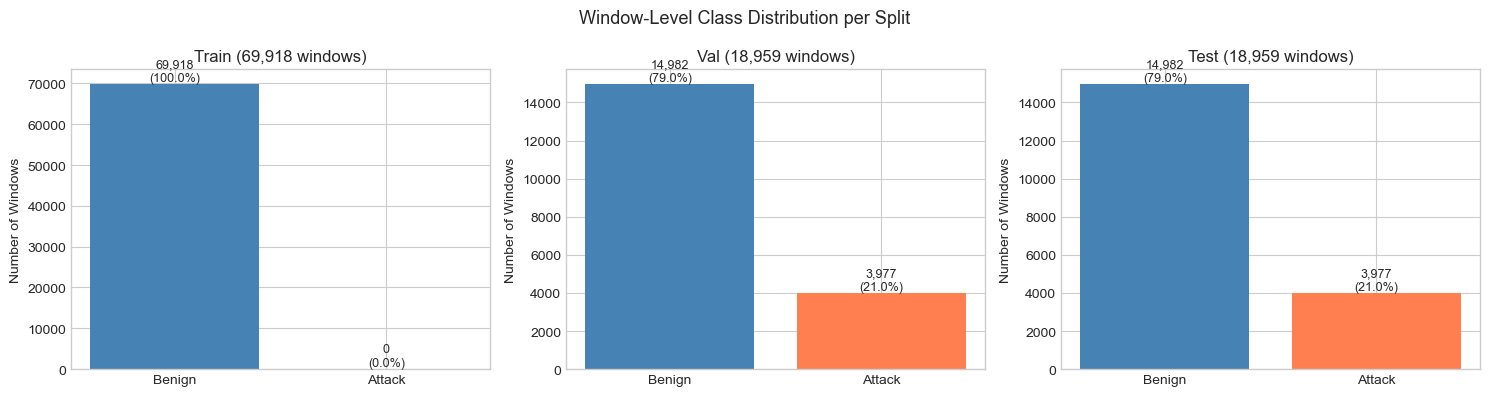

In [27]:
# Visualize class balance at window level
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y) in zip(axes, [("Train", y_train_w), ("Val", y_val_w), ("Test", y_test_w)]):
    counts = [int((y == 0).sum()), int((y == 1).sum())]
    bars = ax.bar(["Benign", "Attack"], counts, color=["steelblue", "coral"])
    ax.set_title(f"{name} ({sum(counts):,} windows)")
    ax.set_ylabel("Number of Windows")
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{count:,}\n({count/sum(counts)*100:.1f}%)",
                ha="center", va="bottom", fontsize=9)

plt.suptitle("Window-Level Class Distribution per Split", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Save Tensors

The preprocessing pipeline (`src/preprocessing.py`) implements all decisions documented above and saves the final tensors. The output structure:

```
data/processed/
├── train_X.pt          # (N_train, 50, N_features) — benign-only windows
├── train_y.pt          # (N_train,)                — all zeros
├── val_X.pt            # (N_val, 50, N_features)   — mixed windows
├── val_y.pt            # (N_val,)                  — 0=benign, 1=attack
├── test_X.pt           # (N_test, 50, N_features)  — mixed windows
├── test_y.pt           # (N_test,)                 — 0=benign, 1=attack
├── scaler.pkl          # RobustScaler fitted on train benign
└── feature_names.pkl   # List of kept feature names
```